# Importar librerías


In [13]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import unicodedata
import warnings

warnings.filterwarnings("ignore")

# EDA


Los Datos fueron generados a través de un sistema de simulación, automatizado para que el código quede mas limpio. Para más información revisar `data-science\src\generar_dataset_transacciones.py`


In [14]:
df_gastos = pd.read_csv("../data/raw/transacciones_simuladas.csv")
df_gastos

,descripcion,categoria,monto
0,COMPRA EN GAS LP,Vivienda,3193.96
1,*camion*,Transporte,47.88
2,COMPRA EN OFFICEMAX,Educación,1445.34
3,COMPRA EN TEATRO,Ocio y Servicios,840.82
4,Teatro,Ocio y Servicios,636.61
...,...,...,...
395,$barberia,Ocio y Servicios,327.08
396,compra diplomado,Educación,1910.03
397,$tortilleria,Alimentación,611.87
398,pago con tarjeta en 7-Eleven,Alimentación,478.18


# Información general del dataset


In [15]:
print("\n1. INFORMACIÓN DE DATASET:")
print(f"Dataset A (Gastos): {len(df_gastos)} registros")


1. INFORMACIÓN DE DATASET:
Dataset A (Gastos): 400 registros


# Verificar datos faltantes


In [16]:
# Verificar datos faltantes
print("\n2. VERIFICACIÓN DE DATOS FALTANTES:")
print("Dataset A:")
print(df_gastos.isnull().sum())


2. VERIFICACIÓN DE DATOS FALTANTES:
Dataset A:
descripcion    0
categoria      0
monto          0
dtype: int64


# Distribución de categorías de gastos


In [17]:
print("\n3. DISTRIBUCIÓN DE CATEGORÍAS:")
distribucion = df_gastos["categoria"].value_counts()
print(distribucion)


3. DISTRIBUCIÓN DE CATEGORÍAS:
categoria
Salud               72
Alimentación        72
Transporte          67
Vivienda            63
Educación           63
Ocio y Servicios    63
Name: count, dtype: int64


# Estadísticas de montos por categoría


In [18]:
print("\n4. ESTADÍSTICAS DE MONTOS POR CATEGORÍA:")
print(df_gastos.groupby("categoria")["monto"].describe())


4. ESTADÍSTICAS DE MONTOS POR CATEGORÍA:
                  count         mean          std     min       25%       50%  \
categoria                                                                       
Alimentación       72.0   408.819306   189.093448   54.14   242.605   402.395   
Educación          63.0  1104.472540   534.660836  109.78   616.035  1203.440   
Ocio y Servicios   63.0   540.662063   268.742924   93.17   307.410   528.250   
Salud              72.0   764.926250   370.240791  136.91   446.490   786.235   
Transporte         67.0   231.065970   148.076718   30.65    98.795   207.760   
Vivienda           63.0  2743.718571  1337.680093  549.48  1584.480  2764.110   

                        75%      max  
categoria                             
Alimentación       543.9275   757.18  
Educación         1492.2900  1983.80  
Ocio y Servicios   747.3250   971.00  
Salud             1092.9025  1486.21  
Transporte         375.2300   499.69  
Vivienda          3972.6650  4887.80

# Crear visualizaciones


#### Gráfico 1: Distribución de categorías


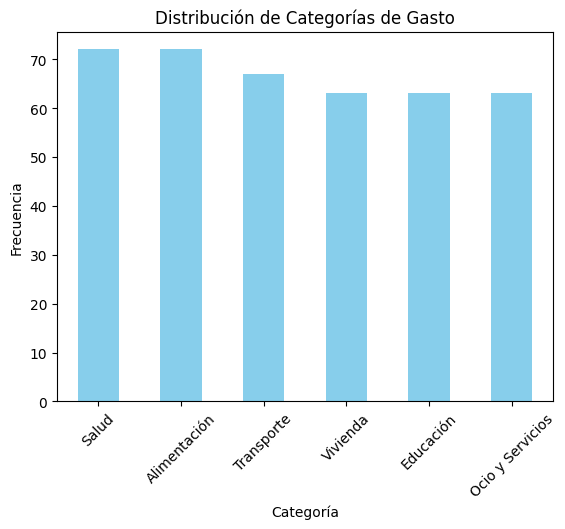

<Figure size 800x500 with 0 Axes>

In [19]:
fig = df_gastos["categoria"].value_counts().plot(kind="bar", color="skyblue")

fig.set_title("Distribución de Categorías de Gasto")
fig.set_xlabel("Categoría")
fig.set_ylabel("Frecuencia")
fig.tick_params(axis="x", rotation=45)

plt.figure(figsize=(8, 5))
plt.tight_layout()
plt.show()

#### Gráfico 2: Boxplot de montos por categoría


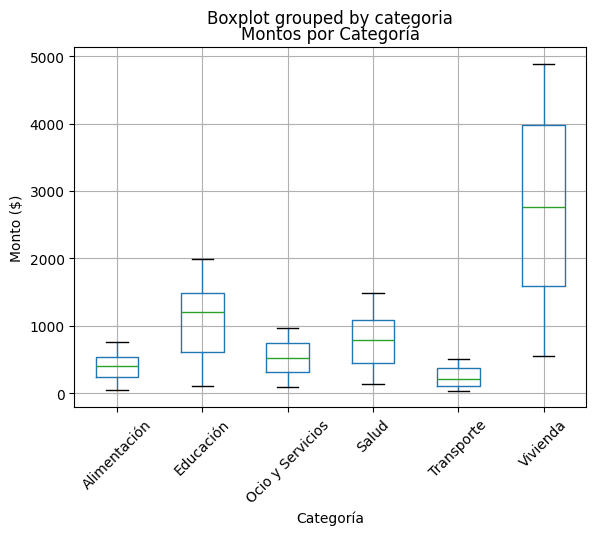

<Figure size 800x500 with 0 Axes>

In [20]:
fig = df_gastos.boxplot(column="monto", by="categoria")

fig.set_title("Montos por Categoría")
fig.set_xlabel("Categoría")
fig.set_ylabel("Monto ($)")
fig.tick_params(axis="x", rotation=45)

plt.figure(figsize=(8, 5))
plt.tight_layout()
plt.show()

# PROCESAMIENTO DE VARIABLES TEXTUALES


In [21]:
def limpiar_texto(texto):
    """Limpia y estandariza texto para NLP"""
    if pd.isna(texto):
        return ""

    # Convertir a minúsculas
    texto = str(texto).lower()

    # Eliminar acentos
    texto = (
        unicodedata.normalize("NFKD", texto).encode("ASCII", "ignore").decode("utf-8")
    )

    # Eliminar caracteres especiales y puntuación
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)

    # Eliminar espacios múltiples
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto


# Crea una lista simple con las stop words en español más comunes
stop_words_es = [
    "de",
    "la",
    "que",
    "el",
    "en",
    "y",
    "a",
    "los",
    "del",
    "se",
    "las",
    "por",
    "un",
    "para",
    "con",
    "no",
    "una",
    "su",
    "al",
    "lo",
    "como",
    "pero",
    "sus",
    "o",
    "este",
    "esta",
    "entre",
    "cuando",
    "sin",
    "sobre",
    "tambien",
    "me",
    "hasta",
    "hay",
    "donde",
    "desde",
    "todo",
    "nos",
    "durante",
    "todos",
    "uno",
    "les",
    "ni",
    "contra",
    "otros",
    "ese",
    "eso",
    "ante",
    "ellos",
    "esto",
]

In [22]:
def procesar_variables_textuales(df_gastos):
    """Procesa las variables textuales con TF-IDF"""
    print("\n" + "=" * 60)
    print("PROCESAMIENTO DE VARIABLES TEXTUALES")
    print("=" * 60)

    # Limpiar texto
    df_gastos["descripcion_limpia"] = df_gastos["descripcion"].apply(limpiar_texto)

    print("\nEjemplos de texto limpio:")
    for i in range(5):
        print(f"Original: {df_gastos.iloc[i]['descripcion']}")
        print(f"Limpio:   {df_gastos.iloc[i]['descripcion_limpia']}")
        print()

    # Vectorización TF-IDF
    vectorizer = TfidfVectorizer(max_features=100, stop_words=stop_words_es)

    # Separar características y etiquetas
    X = df_gastos["descripcion_limpia"]
    y = df_gastos["categoria"]

    # Transformar texto a vectores
    X_tfidf = vectorizer.fit_transform(X)

    print(f"\nDimensiones de la matriz TF-IDF: {X_tfidf.shape}")
    print(f"Número de características: {len(vectorizer.get_feature_names_out())}")

    # Mostrar características más importantes
    feature_names = vectorizer.get_feature_names_out()
    print("\nTop 10 características TF-IDF:")
    for i in range(10):
        print(f"  {i+1}. {feature_names[i]}")

    return vectorizer, X_tfidf, df_gastos

vectorizer, X_tfidf, df_gastos = procesar_variables_textuales(df_gastos)


PROCESAMIENTO DE VARIABLES TEXTUALES

Ejemplos de texto limpio:
Original: COMPRA EN GAS LP
Limpio:   compra en gas lp

Original: *camion*
Limpio:   camion

Original: COMPRA EN OFFICEMAX
Limpio:   compra en officemax

Original: COMPRA EN TEATRO
Limpio:   compra en teatro

Original: Teatro
Limpio:   teatro


Dimensiones de la matriz TF-IDF: (400, 100)
Número de características: 100

Top 10 características TF-IDF:
  1. actividades
  2. aparato
  3. articulo
  4. audiologia
  5. aurrera
  6. axa
  7. basura
  8. belleza
  9. bodega
  10. cablebus


In [23]:
df_gastos

,descripcion,categoria,monto,descripcion_limpia
0,COMPRA EN GAS LP,Vivienda,3193.96,compra en gas lp
1,*camion*,Transporte,47.88,camion
2,COMPRA EN OFFICEMAX,Educación,1445.34,compra en officemax
3,COMPRA EN TEATRO,Ocio y Servicios,840.82,compra en teatro
4,Teatro,Ocio y Servicios,636.61,teatro
...,...,...,...,...
395,$barberia,Ocio y Servicios,327.08,barberia
396,compra diplomado,Educación,1910.03,compra diplomado
397,$tortilleria,Alimentación,611.87,tortilleria
398,pago con tarjeta en 7-Eleven,Alimentación,478.18,pago con tarjeta en 7 eleven


# Guarda el `CSV` procesado

In [24]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "transacciones_procesadas.csv"

df_gastos.to_csv(output_path, sep=",", encoding="utf-8", index=False)